In [4]:
import os, sys

# Go up one level from the notebook folder to project root
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(project_root)

# Add to path for module imports
sys.path.append(project_root)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

# For real-time plotting
from IPython.display import clear_output
import time

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ All imports successful!")
print(f"📱 PyTorch device: {'GPU' if torch.cuda.is_available() else 'CPU'}")

✅ All imports successful!
📱 PyTorch device: CPU


In [6]:
# Load the latest processed data
pattern = "data/processed/AAPL_processed_*.csv"
files = glob.glob(pattern)
latest_file = max(files, key=os.path.getctime)

print(f"📊 Loading: {latest_file}")
df = pd.read_csv(latest_file, index_col='Date', parse_dates=True)

print(f"✅ Loaded {len(df)} rows with {len(df.columns)} columns")
print(f"📅 Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"\n📋 Columns: {list(df.columns)}")
print(f"\n🎯 Target distribution:")
print(df['Target'].value_counts())

📊 Loading: data/processed/AAPL_processed_20250628_174810.csv
✅ Loaded 6403 rows with 36 columns
📅 Date range: 2000-01-11 to 2025-06-26

📋 Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper', 'BB_Middle', 'BB_Lower', 'BB_Width', 'BB_Position', 'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26', 'OBV', 'ATR', 'ROC', 'Stoch_K', 'Stoch_D', 'Close_Return', 'Close_Return_Log', 'High_Low_Ratio', 'Close_Open_Ratio', 'High_Close_Ratio', 'Low_Close_Ratio', 'Volume_MA', 'Volume_Ratio', 'High_Low_Pct', 'Price_Range', 'Close_vs_SMA20', 'Close_vs_SMA50', 'Target']

🎯 Target distribution:
Target
1    3337
0    3066
Name: count, dtype: int64


In [7]:
class StockDataset(Dataset):
    """PyTorch Dataset for stock sequences"""
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def prepare_data(df, lookback_days=30):
    """Prepare data for LSTM training"""
    
    # Separate features and target
    feature_cols = [col for col in df.columns if col != 'Target']
    X = df[feature_cols].values
    y = df['Target'].values
    
    # Scale features
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Create sequences
    X_sequences = []
    y_sequences = []
    
    for i in range(lookback_days, len(X_scaled)):
        X_sequences.append(X_scaled[i-lookback_days:i])
        y_sequences.append(y[i])
    
    X_seq = np.array(X_sequences)
    y_seq = np.array(y_sequences)
    
    print(f"📦 Created {len(X_seq)} sequences")
    print(f"📊 Sequence shape: {X_seq.shape}")
    
    return X_seq, y_seq, scaler, feature_cols

# Prepare the data
X_seq, y_seq, scaler, feature_cols = prepare_data(df, lookback_days=30)

📦 Created 6373 sequences
📊 Sequence shape: (6373, 30, 35)


In [8]:
def split_time_series(X_seq, y_seq, train_ratio=0.7, val_ratio=0.15):
    """Split data maintaining time order"""
    n_samples = len(X_seq)
    
    train_end = int(n_samples * train_ratio)
    val_end = int(n_samples * (train_ratio + val_ratio))
    
    X_train = X_seq[:train_end]
    X_val = X_seq[train_end:val_end]
    X_test = X_seq[val_end:]
    
    y_train = y_seq[:train_end]
    y_val = y_seq[train_end:val_end]
    y_test = y_seq[val_end:]
    
    print(f"📊 Data splits:")
    print(f"   Train: {len(X_train)} samples")
    print(f"   Validation: {len(X_val)} samples") 
    print(f"   Test: {len(X_test)} samples")
    
    return (X_train, X_val, X_test), (y_train, y_val, y_test)

# Split the data
(X_train, X_val, X_test), (y_train, y_val, y_test) = split_time_series(X_seq, y_seq)

# Create data loaders
train_dataset = StockDataset(X_train, y_train)
val_dataset = StockDataset(X_val, y_val)
test_dataset = StockDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("✅ Data loaders created!")

📊 Data splits:
   Train: 4461 samples
   Validation: 956 samples
   Test: 956 samples
✅ Data loaders created!


In [9]:
class StockLSTM(nn.Module):
    """PyTorch LSTM model for stock prediction"""
    
    def __init__(self, input_size, hidden_size=50, num_layers=2, dropout=0.2):
        super(StockLSTM, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layers
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )
        
        # Dense layers
        self.fc1 = nn.Linear(hidden_size, 25)
        self.dropout = nn.Dropout(0.1)
        self.fc2 = nn.Linear(25, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_output = lstm_out[:, -1, :]
        out = F.relu(self.fc1(last_output))
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.sigmoid(out)
        return out

# Create model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_size = X_seq.shape[2]  # Number of features
model = StockLSTM(input_size=input_size).to(device)

print(f"🤖 Model created on device: {device}")
print(f"📊 Input size: {input_size} features")
print(f"📈 Model summary:")
print(model)

🤖 Model created on device: cpu
📊 Input size: 35 features
📈 Model summary:
StockLSTM(
  (lstm): LSTM(35, 50, num_layers=2, batch_first=True, dropout=0.2)
  (fc1): Linear(in_features=50, out_features=25, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc2): Linear(in_features=25, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [10]:
# Training parameters
learning_rate = 0.001
epochs = 50
patience = 10

# Loss and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training history storage
history = {
    'train_loss': [],
    'val_loss': [],
    'train_accuracy': [],
    'val_accuracy': []
}

print(f"🔧 Training setup complete!")
print(f"   Learning rate: {learning_rate}")
print(f"   Max epochs: {epochs}")
print(f"   Early stopping patience: {patience}")

🔧 Training setup complete!
   Learning rate: 0.001
   Max epochs: 50
   Early stopping patience: 10


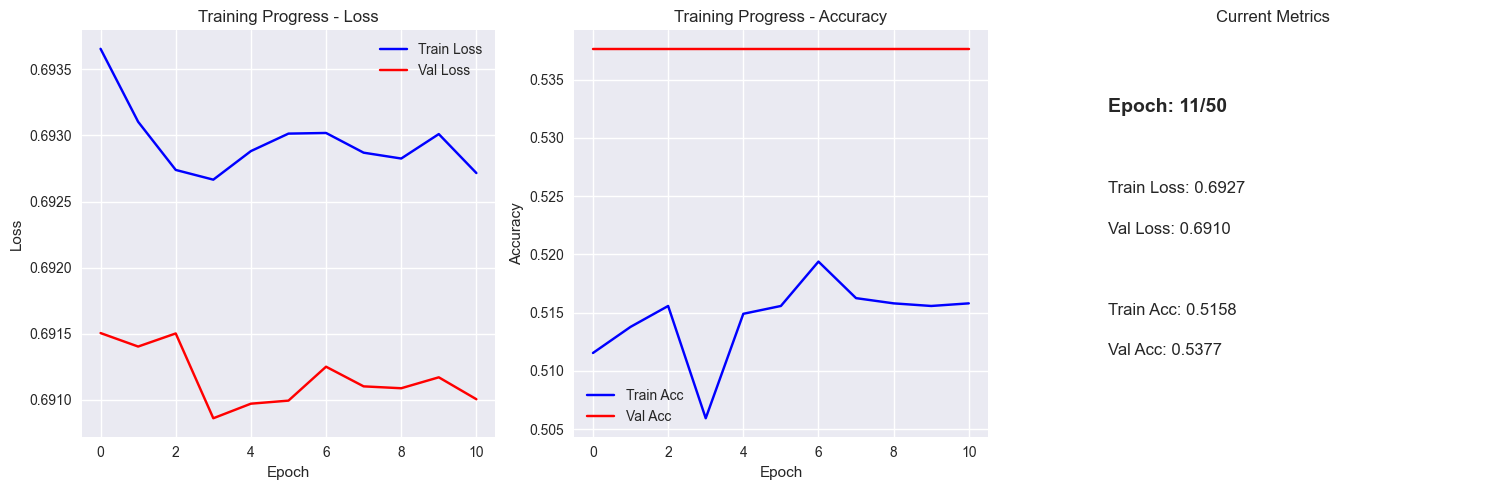

Epoch  11/50 | Train Loss: 0.6927 | Val Loss: 0.6910 | Train Acc: 0.5158 | Val Acc: 0.5377
Epoch  12/50 | Train Loss: 0.6929 | Val Loss: 0.6910 | Train Acc: 0.5160 | Val Acc: 0.5377
Epoch  13/50 | Train Loss: 0.6928 | Val Loss: 0.6910 | Train Acc: 0.5160 | Val Acc: 0.5377
Epoch  14/50 | Train Loss: 0.6929 | Val Loss: 0.6910 | Train Acc: 0.5160 | Val Acc: 0.5377

🛑 Early stopping at epoch 14

✅ Training completed!


In [11]:
# Training loop with real-time visualization
best_val_loss = float('inf')
patience_counter = 0

plt.figure(figsize=(15, 5))

for epoch in range(epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X).squeeze()
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        predicted = (outputs > 0.5).float()
        train_total += batch_y.size(0)
        train_correct += (predicted == batch_y).sum().item()
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X).squeeze()
            loss = criterion(outputs, batch_y)
            
            val_loss += loss.item()
            predicted = (outputs > 0.5).float()
            val_total += batch_y.size(0)
            val_correct += (predicted == batch_y).sum().item()
    
    # Calculate averages
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total
    
    # Store history
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_accuracy'].append(train_acc)
    history['val_accuracy'].append(val_acc)
    
    # Real-time plotting
    if epoch % 5 == 0:  # Update plot every 5 epochs
        clear_output(wait=True)
        
        plt.figure(figsize=(15, 5))
        
        # Loss plot
        plt.subplot(1, 3, 1)
        plt.plot(history['train_loss'], label='Train Loss', color='blue')
        plt.plot(history['val_loss'], label='Val Loss', color='red')
        plt.title('Training Progress - Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        
        # Accuracy plot
        plt.subplot(1, 3, 2)
        plt.plot(history['train_accuracy'], label='Train Acc', color='blue')
        plt.plot(history['val_accuracy'], label='Val Acc', color='red')
        plt.title('Training Progress - Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True)
        
        # Current metrics
        plt.subplot(1, 3, 3)
        plt.text(0.1, 0.8, f'Epoch: {epoch+1}/{epochs}', fontsize=14, weight='bold')
        plt.text(0.1, 0.6, f'Train Loss: {avg_train_loss:.4f}', fontsize=12)
        plt.text(0.1, 0.5, f'Val Loss: {avg_val_loss:.4f}', fontsize=12)
        plt.text(0.1, 0.3, f'Train Acc: {train_acc:.4f}', fontsize=12)
        plt.text(0.1, 0.2, f'Val Acc: {val_acc:.4f}', fontsize=12)
        plt.xlim(0, 1)
        plt.ylim(0, 1)
        plt.axis('off')
        plt.title('Current Metrics')
        
        plt.tight_layout()
        plt.show()
    
    # Print progress
    print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    
    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), 'models/best_model_temp.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n🛑 Early stopping at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict(torch.load('models/best_model_temp.pth'))
print("\n✅ Training completed!")

📊 Final Test Results:
   Accuracy: 0.5272 (52.72%)

📋 Classification Report:
              precision    recall  f1-score   support

        Down       0.00      0.00      0.00       452
          Up       0.53      1.00      0.69       504

    accuracy                           0.53       956
   macro avg       0.26      0.50      0.35       956
weighted avg       0.28      0.53      0.36       956



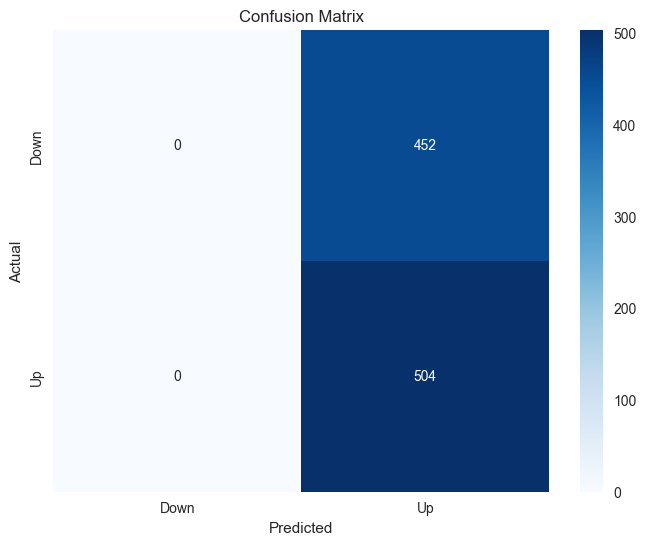

In [12]:
# Evaluate on test set
model.eval()
y_true = []
y_pred = []
y_pred_proba = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model(batch_X).squeeze()
        predicted = (outputs > 0.5).float()
        
        y_true.extend(batch_y.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        y_pred_proba.extend(outputs.cpu().numpy())

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)

print(f"📊 Final Test Results:")
print(f"   Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Down', 'Up']))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
# Final training history plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training History - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['train_accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Training History - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Save final model
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
model_file = f"models/AAPL_pytorch_lstm_{timestamp}.pth"
torch.save(model.state_dict(), model_file)

import joblib
scaler_file = f"models/AAPL_scaler_{timestamp}.pkl"
joblib.dump(scaler, scaler_file)

print(f"💾 Model saved: {model_file}")
print(f"💾 Scaler saved: {scaler_file}")

# Performance summary
print(f"\n🎉 Training Summary:")
print(f"   📊 Final test accuracy: {accuracy:.1%}")
print(f"   📈 Total epochs trained: {len(history['train_loss'])}")
print(f"   🎯 Best validation loss: {best_val_loss:.4f}")

if accuracy > 0.55:
    print(f"✅ Good result! {accuracy:.1%} is above random chance")
else:
    print(f"⚠️  Result close to random. Consider adjusting hyperparameters")